**Analyzing Alzheimer’s Gene Expression**

Alzheimer’s disease is a neurogenerative disorder characterized by progressive cognitive decline and changes in gene expression within the brain. Understanding how specific genes behave in Alzheimer’s patients compared to healthy controls can help identify biological pathways involved in the disease. In this analysis, we examined three genes of interest: IL17C, TEK, and CCL4. These genes were selected due to their roles in inflammation and vascular function, two processes known to be altered in Alzheimer’s disease. By comparing mean expression levels and fold change values, we aimed to identify early patterns that may indicate dysregulation in Alzheimer’s pathology.

**Methods**


*   Data source: Norm_NR.txt microarray dataset
*   Software: Google Colab, Python, pandas, matplotlib



**Steps:**

In [1]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [13]:
ls drive/MyDrive/Bio_2110/

'Assignment# 8.ipynb'              'Lab week #10'
'Assignmnet#7 .ipynb'               measles_2025_cases.csv
'Copy of week10.ipynb'              my_file.txt
'Copy of week8.ipynb'               my_ids.txt
 data.txt                           my_patients.txt
 dna_sequence.txt                   Norm_NR.txt
 FinalProject.ipynb                 patients_ids.txt
 hospital_general_information.csv   patients_needing_attention.csv
 influenza_vaccination.csv          patients.txt
 Lab#10.ipynb                       Review.ipynb
 Lab#12.ipynb                       severe_patients.txt
'Lab #8 assignment.ipynb'           specialist_focus.txt
'Lab #9 in class.ipynb'             text.txt
 Lab#9.ipynb                       'Week #10.ipynb'


**Loaded expression data from Norm_NR.txt**

In [20]:
import pandas as pd

df = pd.read_csv("/content/drive/MyDrive/Bio_2110/Norm_NR.txt", sep="\t")
df.head(20)

,1|,CDA02,CDA07,CDA08,CDA10,CDA18,CDA19,CDA20,CDA21,CDA22,...,PDA40,PDA41,PDA42,PDA43,PDA45,PDA46,PDA47,PDA48,PDA50,PDA51
0,2|ATP6V0D2|A_23_P146146,4.418733,4.622400,4.633319,NaN,4.193991,2.462685,3.960489,4.526529,4.824808,...,4.867448,4.281042,4.346414,4.665537,4.606425,4.555337,4.024444,4.117435,3.735035,2.973707
1,3|BRAF|A_23_P42935,8.559224,8.093108,7.889055,8.084263,7.722801,7.419349,7.834918,8.236317,8.173981,...,8.266885,8.163516,7.748073,8.037113,7.912422,7.827035,7.914707,7.582702,7.556120,7.503222
2,4|HEBP1|A_23_P117082,11.436178,12.012774,11.768550,11.655533,11.650989,11.744913,11.747606,11.773529,11.490449,...,11.657658,11.646546,11.401445,11.447848,10.928976,11.082646,11.424068,11.267427,11.535292,11.220294
3,5|RPAP3|A_23_P2683,8.412936,7.916365,7.289811,7.559604,8.576711,8.062906,7.228723,8.866619,8.424358,...,8.476980,8.561777,8.128072,7.887290,8.493502,8.695611,8.419379,8.379625,8.647275,8.771615
4,6|A_24_P358131|A_24_P358131,6.024123,6.026219,5.772629,4.565060,5.358188,5.519439,5.408293,5.946741,5.619399,...,4.020311,6.049043,5.832769,6.156636,6.357067,5.999590,5.885670,5.843561,5.429757,5.541111
5,7|ECT2L|A_33_P3367647,4.993845,5.100716,4.513241,NaN,5.226379,4.530310,4.736012,4.989444,4.839777,...,4.783816,4.855243,5.060713,4.883664,4.685540,4.893114,4.613452,5.107860,4.802539,4.643201
6,8|C7orf34|A_23_P157316,6.814961,6.366713,5.602049,3.838262,7.418060,6.712216,7.279165,6.790636,6.589102,...,6.782804,7.371486,6.648335,7.176172,6.498713,8.548372,6.783615,7.259116,6.593815,6.638376
7,9|ENST00000429990|A_32_P14850,14.958883,14.212648,14.468967,14.694162,14.147164,14.198526,14.112658,15.094086,14.560397,...,14.199069,14.391254,13.845745,14.415225,14.679106,14.189433,13.993499,14.418575,14.292989,14.400834
8,10|AGTRAP|A_23_P158596,10.810539,11.602530,11.009100,11.022591,11.422932,10.993186,11.319584,10.789305,11.162221,...,11.576127,11.537517,11.333414,10.985245,10.557832,11.065012,11.198515,11.043161,11.347977,11.011647
9,11|TRIM56|A_23_P350107,11.711820,11.081265,11.261775,11.330805,11.449705,11.109211,11.346721,11.643023,11.469396,...,11.309934,11.722601,11.117084,11.851735,11.465902,11.819053,11.642919,11.461226,11.398517,11.429684


**Parsed gene identifiers into RowID, GeneSymbol, and ProbeID**

In [21]:
df[['RowID', 'GeneSymbol', 'ProbeID']] = df.iloc[:,0].str.split('|', expand=True)

df = df.drop(df.columns[0], axis=1)

df.head(20)

,CDA02,CDA07,CDA08,CDA10,CDA18,CDA19,CDA20,CDA21,CDA22,CDA23,...,PDA43,PDA45,PDA46,PDA47,PDA48,PDA50,PDA51,RowID,GeneSymbol,ProbeID
0,4.418733,4.622400,4.633319,NaN,4.193991,2.462685,3.960489,4.526529,4.824808,5.325140,...,4.665537,4.606425,4.555337,4.024444,4.117435,3.735035,2.973707,2,ATP6V0D2,A_23_P146146
1,8.559224,8.093108,7.889055,8.084263,7.722801,7.419349,7.834918,8.236317,8.173981,8.299522,...,8.037113,7.912422,7.827035,7.914707,7.582702,7.556120,7.503222,3,BRAF,A_23_P42935
2,11.436178,12.012774,11.768550,11.655533,11.650989,11.744913,11.747606,11.773529,11.490449,11.874075,...,11.447848,10.928976,11.082646,11.424068,11.267427,11.535292,11.220294,4,HEBP1,A_23_P117082
3,8.412936,7.916365,7.289811,7.559604,8.576711,8.062906,7.228723,8.866619,8.424358,8.347132,...,7.887290,8.493502,8.695611,8.419379,8.379625,8.647275,8.771615,5,RPAP3,A_23_P2683
4,6.024123,6.026219,5.772629,4.565060,5.358188,5.519439,5.408293,5.946741,5.619399,5.991535,...,6.156636,6.357067,5.999590,5.885670,5.843561,5.429757,5.541111,6,A_24_P358131,A_24_P358131
5,4.993845,5.100716,4.513241,NaN,5.226379,4.530310,4.736012,4.989444,4.839777,5.363765,...,4.883664,4.685540,4.893114,4.613452,5.107860,4.802539,4.643201,7,ECT2L,A_33_P3367647
6,6.814961,6.366713,5.602049,3.838262,7.418060,6.712216,7.279165,6.790636,6.589102,7.008020,...,7.176172,6.498713,8.548372,6.783615,7.259116,6.593815,6.638376,8,C7orf34,A_23_P157316
7,14.958883,14.212648,14.468967,14.694162,14.147164,14.198526,14.112658,15.094086,14.560397,14.752893,...,14.415225,14.679106,14.189433,13.993499,14.418575,14.292989,14.400834,9,ENST00000429990,A_32_P14850
8,10.810539,11.602530,11.009100,11.022591,11.422932,10.993186,11.319584,10.789305,11.162221,11.838910,...,10.985245,10.557832,11.065012,11.198515,11.043161,11.347977,11.011647,10,AGTRAP,A_23_P158596
9,11.711820,11.081265,11.261775,11.330805,11.449705,11.109211,11.346721,11.643023,11.469396,11.687885,...,11.851735,11.465902,11.819053,11.642919,11.461226,11.398517,11.429684,11,TRIM56,A_23_P350107


In [23]:
df = df[["GeneSymbol", "RowID", "ProbeID"] +
        [col for col in df.columns if col not in ["GeneSymbol", "RowID", "ProbeID"]]]

df.head()

,GeneSymbol,RowID,ProbeID,CDA02,CDA07,CDA08,CDA10,CDA18,CDA19,CDA20,...,PDA40,PDA41,PDA42,PDA43,PDA45,PDA46,PDA47,PDA48,PDA50,PDA51
0,ATP6V0D2,2,A_23_P146146,4.418733,4.622400,4.633319,NaN,4.193991,2.462685,3.960489,...,4.867448,4.281042,4.346414,4.665537,4.606425,4.555337,4.024444,4.117435,3.735035,2.973707
1,BRAF,3,A_23_P42935,8.559224,8.093108,7.889055,8.084263,7.722801,7.419349,7.834918,...,8.266885,8.163516,7.748073,8.037113,7.912422,7.827035,7.914707,7.582702,7.556120,7.503222
2,HEBP1,4,A_23_P117082,11.436178,12.012774,11.768550,11.655533,11.650989,11.744913,11.747606,...,11.657658,11.646546,11.401445,11.447848,10.928976,11.082646,11.424068,11.267427,11.535292,11.220294
3,RPAP3,5,A_23_P2683,8.412936,7.916365,7.289811,7.559604,8.576711,8.062906,7.228723,...,8.476980,8.561777,8.128072,7.887290,8.493502,8.695611,8.419379,8.379625,8.647275,8.771615
4,A_24_P358131,6,A_24_P358131,6.024123,6.026219,5.772629,4.565060,5.358188,5.519439,5.408293,...,4.020311,6.049043,5.832769,6.156636,6.357067,5.999590,5.885670,5.843561,5.429757,5.541111


In [24]:
genes_of_interest = df[df["GeneSymbol"].isin(["IL17C", "TEK", "CCL4"])]
genes_of_interest

,GeneSymbol,RowID,ProbeID,CDA02,CDA07,CDA08,CDA10,CDA18,CDA19,CDA20,...,PDA40,PDA41,PDA42,PDA43,PDA45,PDA46,PDA47,PDA48,PDA50,PDA51
7758,IL17C,7760,A_33_P3339625,7.422642,7.637250,7.132393,5.932981,6.307125,6.025233,6.337528,...,6.575854,7.139788,6.830727,6.945090,7.009832,6.694037,5.801696,6.663668,6.102661,6.060316
19102,CCL4,19104,A_33_P3354607,13.229366,13.412605,13.292865,12.472190,12.788399,12.835094,13.311564,...,13.417704,13.838163,13.698509,13.744565,13.430145,13.073824,13.152166,13.726648,13.353820,12.570126
22894,CCL4,22896,A_23_P207564,13.826579,13.930760,13.816421,12.862285,13.279946,13.319075,13.837233,...,13.799038,14.190087,13.994541,14.201568,13.897029,13.631628,13.651011,14.090725,13.872736,13.142229
28609,TEK,28611,A_23_P374695,6.487169,4.591139,6.568073,5.269507,6.337528,5.025308,5.454256,...,5.919118,5.818934,5.891493,5.443915,4.624521,7.823865,5.925371,5.697204,5.185757,4.675555


**Separated control (CDA) and Alzheimer’s (PDA) samples**

In [29]:
control_cols = [col for col in df.columns if col.startswith("CDA")]

alz_cols = [col for col in df.columns if col.startswith("PDA")]

df["Control_mean"] = df[control_cols].mean(axis=1)
df["Alz_mean"] = df[alz_cols].mean(axis=1)
df["FoldChange"] = df["Alz_mean"] - df["Control_mean"]

df.head()

,GeneSymbol,RowID,ProbeID,CDA02,CDA07,CDA08,CDA10,CDA18,CDA19,CDA20,...,PDA43,PDA45,PDA46,PDA47,PDA48,PDA50,PDA51,Control_mean,Alz_mean,FoldChange
0,ATP6V0D2,2,A_23_P146146,4.418733,4.622400,4.633319,NaN,4.193991,2.462685,3.960489,...,4.665537,4.606425,4.555337,4.024444,4.117435,3.735035,2.973707,4.239566,4.223912,-0.015654
1,BRAF,3,A_23_P42935,8.559224,8.093108,7.889055,8.084263,7.722801,7.419349,7.834918,...,8.037113,7.912422,7.827035,7.914707,7.582702,7.556120,7.503222,8.026897,7.920423,-0.106474
2,HEBP1,4,A_23_P117082,11.436178,12.012774,11.768550,11.655533,11.650989,11.744913,11.747606,...,11.447848,10.928976,11.082646,11.424068,11.267427,11.535292,11.220294,11.684004,11.383563,-0.300441
3,RPAP3,5,A_23_P2683,8.412936,7.916365,7.289811,7.559604,8.576711,8.062906,7.228723,...,7.887290,8.493502,8.695611,8.419379,8.379625,8.647275,8.771615,8.218218,8.326487,0.108269
4,A_24_P358131,6,A_24_P358131,6.024123,6.026219,5.772629,4.565060,5.358188,5.519439,5.408293,...,6.156636,6.357067,5.999590,5.885670,5.843561,5.429757,5.541111,5.631804,5.623674,-0.008130


In [30]:
genes = ["IL17C", "TEK", "CCL4"]
subset = df[df["GeneSymbol"].isin(genes)]
subset

,GeneSymbol,RowID,ProbeID,CDA02,CDA07,CDA08,CDA10,CDA18,CDA19,CDA20,...,PDA43,PDA45,PDA46,PDA47,PDA48,PDA50,PDA51,Control_mean,Alz_mean,FoldChange
7758,IL17C,7760,A_33_P3339625,7.422642,7.637250,7.132393,5.932981,6.307125,6.025233,6.337528,...,6.945090,7.009832,6.694037,5.801696,6.663668,6.102661,6.060316,6.695537,6.873259,0.177721
19102,CCL4,19104,A_33_P3354607,13.229366,13.412605,13.292865,12.472190,12.788399,12.835094,13.311564,...,13.744565,13.430145,13.073824,13.152166,13.726648,13.353820,12.570126,13.094788,13.626846,0.532058
22894,CCL4,22896,A_23_P207564,13.826579,13.930760,13.816421,12.862285,13.279946,13.319075,13.837233,...,14.201568,13.897029,13.631628,13.651011,14.090725,13.872736,13.142229,13.570006,14.077097,0.507091
28609,TEK,28611,A_23_P374695,6.487169,4.591139,6.568073,5.269507,6.337528,5.025308,5.454256,...,5.443915,4.624521,7.823865,5.925371,5.697204,5.185757,4.675555,5.387521,5.689869,0.302348


**Calculated Control_mean, Alz_mean, and FoldChange (Alz_mean − Control_mean)**

In [31]:
table1 = subset[["GeneSymbol", "Control_mean", "Alz_mean"]]
table1

,GeneSymbol,Control_mean,Alz_mean
7758,IL17C,6.695537,6.873259
19102,CCL4,13.094788,13.626846
22894,CCL4,13.570006,14.077097
28609,TEK,5.387521,5.689869


Table 1. Mean expression values for IL17C, TEK, and CCL4 in control and Alzheimer’s samples.  
All three genes show higher average expression in Alzheimer’s patients compared to controls. CCL4 has the highest mean expression across both probes, reflecting its strong involvement in inflammatory signaling. TEK shows moderate expression levels, consistent with its vascular‑related function. IL17C shows lower overall expression but still increases in Alzheimer’s samples. Note: CCL4 appears twice because the dataset includes two different probes for the same gene, which is expected and not a duplication error.

In [32]:
table2 = subset[["GeneSymbol", "FoldChange"]]
table2

,GeneSymbol,FoldChange
7758,IL17C,0.177721
19102,CCL4,0.532058
22894,CCL4,0.507091
28609,TEK,0.302348


Table 2. Fold change values for IL17C, TEK, and CCL4 comparing Alzheimer’s samples to controls.  
Positive fold change values indicate higher expression in Alzheimer’s patients. CCL4 shows the strongest upregulation across both probes, suggesting increased inflammatory activity associated with Alzheimer’s disease. TEK displays moderate upregulation, while IL17C shows a smaller increase but still follows the same upward trend. These fold‑change values highlight which genes may be most responsive to disease‑related changes.

In [33]:
table3 = subset[["GeneSymbol", "Control_mean", "Alz_mean", "FoldChange"]]
table3

,GeneSymbol,Control_mean,Alz_mean,FoldChange
7758,IL17C,6.695537,6.873259,0.177721
19102,CCL4,13.094788,13.626846,0.532058
22894,CCL4,13.570006,14.077097,0.507091
28609,TEK,5.387521,5.689869,0.302348


Table 3. Summary of mean expression and fold change for IL17C, TEK, and CCL4 in control and Alzheimer’s samples.  
All three genes show higher expression in Alzheimer’s patients, with CCL4 displaying the strongest increase across both probes. TEK shows moderate upregulation, while IL17C shows a smaller but consistent rise. Note: CCL4 appears twice because the dataset includes two different probes for the same gene, which is expected and not a duplication error.

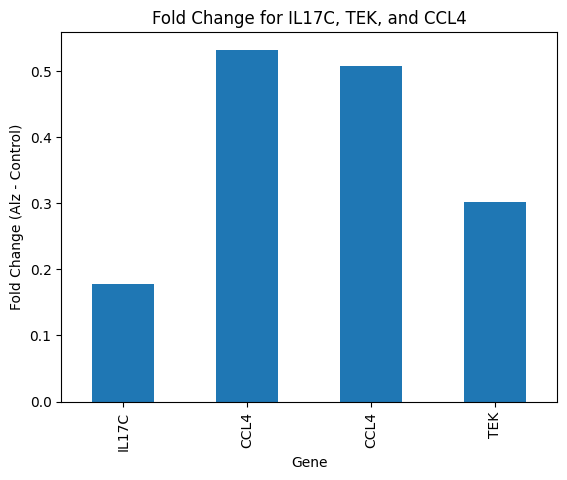

In [34]:
import matplotlib.pyplot as plt

subset.set_index("GeneSymbol")["FoldChange"].plot(kind="bar")

plt.title("Fold Change for IL17C, TEK, and CCL4")
plt.ylabel("Fold Change (Alz - Control)")
plt.xlabel("Gene")
plt.show()

Figure 1. Bar chart of fold change for IL17C, TEK, and CCL4.  
CCL4 shows the strongest increase, TEK shows moderate upregulation, and IL17C shows a smaller rise.

**References**

Abed, S., Ebrahimi, A., Fattahi, F., Shekari-Khaniani, M., & Mansoori Derakhshan, S. (2025). Revolutionizing Alzheimer’s Detection: Immune-Related Gene Biomarkers as Non-Invasive Predictors. Molecular Neurobiology, 62(9), 11517–11528. https://doi.org/10.1007/s12035-025-04970-x

https://ftp.ebi.ac.uk/biostudies/fire/E-MTAB-/094/E-MTAB-6094/Files/Norm_NR.txt
